# **Mineração e Visualização de Dados**
### **Pontifícia Universidade Católica de Campinas**
### **Prof. Fernando de Aguiar Neto**
### **Integrantes**
- Rafael Franco - 25897109
- Pedro Botto - 26008504
- Pedro Capoulade - 26007499
- Beathriz Ivanoff - 23006404



### Importação de Bibliotecas

In [3]:
from scipy.io.arff import loadarff
import numpy as np
import pandas as pd

### Carregamento de DataFrame do Supermercado (Supermarket)

### GITHUB

In [4]:
data, meta = loadarff('/content/supermarket.arff')

### Exibição de DataFrame

In [5]:
data_np = np.array(data)
df = pd.DataFrame(data_np, dtype=str)
df

,department1,department2,department3,department4,department5,department6,department7,department8,department9,grocery misc,...,department208,department209,department210,department211,department212,department213,department214,department215,department216,total
0,?,?,?,?,?,?,?,?,?,?,...,?,?,?,?,?,?,?,?,?,high
1,t,?,?,?,?,?,?,?,?,?,...,?,?,?,?,?,?,?,?,?,low
2,?,?,?,?,?,?,?,?,?,?,...,?,?,?,?,?,?,?,?,?,low
3,t,?,?,?,?,?,?,?,?,?,...,?,?,?,?,?,?,?,?,?,low
4,?,?,?,?,?,?,?,?,?,?,...,?,?,?,?,?,?,?,?,?,low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4622,?,?,?,?,?,?,?,?,?,?,...,?,?,?,?,?,?,?,?,?,low
4623,?,?,?,t,?,?,?,?,?,?,...,?,?,?,?,?,?,?,?,?,high
4624,?,?,?,?,?,?,?,?,?,?,...,?,?,?,?,?,?,?,?,?,low
4625,?,?,?,?,?,?,?,?,?,?,...,?,?,?,?,?,?,?,?,?,low


### Conversão de DataFrame com os Filtros para Arquivo Excel

In [6]:
df.to_csv('supermarket.csv', index=False)

In [7]:
'''supermarket = pd.read_csv('/content/supermarket.csv')
supermarket.head()'''

"supermarket = pd.read_csv('/content/supermarket.csv')\nsupermarket.head()"

### Remoção de colunas vazias e Remoção de departamentos

In [8]:
# Remove as colunas "department"
df_limpo = df.loc[:, ~df.columns.str.startswith('department')]

# Troca "?" por NaN
df_limpo = df_limpo.replace('?', np.nan)

# Exclui as colunas com o "NaN" (estão vazias)
df_limpo = df_limpo.dropna(axis=1, how='all')

# Substitui NaN por "?"
df_limpo = df_limpo.replace(np.nan, '?')

df_limpo

/tmp/ipykernel_571/93792623.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_limpo = df_limpo.replace('?', np.nan)


,grocery misc,baby needs,bread and cake,baking needs,juice-sat-cord-ms,tea,biscuits,canned fish-meat,canned fruit,canned vegetables,...,casks red wine,750ml white nz,750ml red nz,750ml white imp,750ml red imp,sparkling nz,sparkling imp,port and sherry,non host support,total
0,?,t,t,t,t,?,t,?,?,t,...,?,t,?,?,?,?,?,?,?,high
1,?,?,?,?,?,?,?,t,t,t,...,?,?,?,?,?,?,?,?,?,low
2,?,?,t,t,t,?,t,?,t,?,...,?,?,?,?,?,?,?,?,?,low
3,?,?,t,t,t,?,t,?,?,t,...,?,?,?,?,?,?,?,?,?,low
4,?,?,t,t,t,t,?,?,?,?,...,?,?,?,?,?,?,?,?,?,low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4622,?,?,t,t,t,?,t,?,t,t,...,?,?,?,?,?,?,?,?,?,low
4623,?,?,t,t,t,?,t,?,t,t,...,?,?,?,?,?,?,?,?,?,high
4624,?,?,?,?,?,?,?,?,?,?,...,?,?,?,?,?,?,?,?,?,low
4625,?,t,?,t,?,?,?,?,?,?,...,?,?,?,?,?,?,?,?,?,low


### Conversão de DataFrame Filtrado para Arquivo `csv`

In [9]:
df_limpo.to_csv('supermarket_filtrado.csv', index=False)

## **Resumo Confiança, Lift e Leverage**

---

**Confiança (Confidence):**
Mostra a chance de algo acontecer junto. Por exemplo, se a confiança é 0,9 (90%), significa que de cada 10 pessoas que compram um produto, 9 também compram o outro.






**Lift:**
Mostra se a relação entre os produtos é realmente importante ou só coincidência.

* Maior que 1 → os produtos têm relação positiva
* Igual a 1 → não têm relação
* Menor que 1 → relação negativa


**Leverage (Alavancagem):**
Mostra o quanto essa combinação acontece a mais do que o esperado. Ou seja, indica se essa compra conjunta realmente faz diferença na prática.



---

# **1. Regra**

**Grupo A (biscuits=t frozen foods=t fruit=t total=high 788)**

**Grupo B (bread and cake=t)** 723  

Grupo A ==> Grupo B


*   Confiança: 0.92
*   Lift: 1.27
*   Leverage: 0.03

### Configurações do Apriori

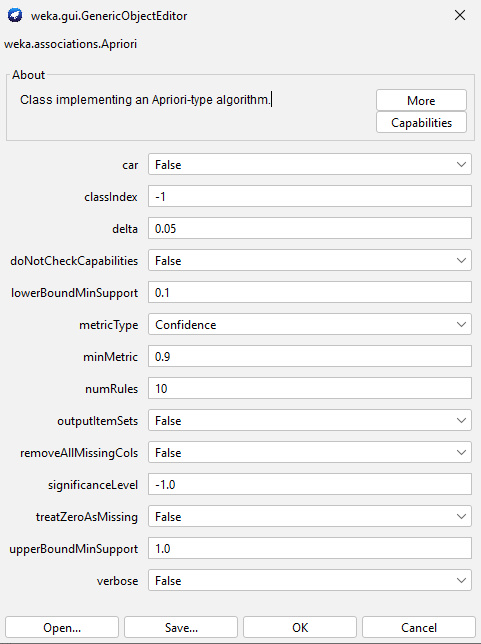

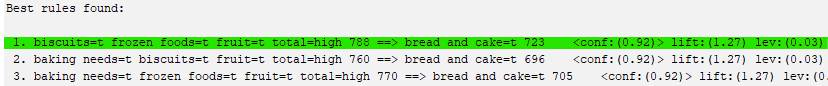

---

### *Análise da 1ª Regra:*

- A confiança (0.92) aponta que 92% das pessoas que compram os itens do Grupo A (Biscoitos, Comida Congelada e Fruta) tendem a comprar os produtos do Grupo B (Pão e Bolo).

- O Lift por ser (1.27), ou seja, maior que 1, aponta que o Grupo A e o Grupo B são positivamente associados (o antecedente impulsiona o consequente). Então, isso significa que comprar o Grupo A aumenta em 27% a probabilidade de comprar o Grupo B.

- O Leverage ou Alavancagem por ser (0.03) aponta que há uma diferença positiva entre a ocorrência real e a esperada da compra conjunta entre o Grupo A e o Grupo B. Ou seja, isso indica que a compra dos itens do Grupo A aumenta em 3% a ocorrência de compras do Grupo B.

### *Cenário da 1ª Regra:*

Observa-se que **consumidores que compram itens do Grupo A (biscoitos, comidas congeladas e frutas) também possuem alta tendência de comprar itens do Grupo B (pão e bolo).** Esse comportamento pode estar relacionado a situações específicas do dia a dia, como por exemplo, um **café da manhã ou até mesmo um lanche da tarde.**

### *Intervenção da 1ª Regra:*

Com base nessa regra, o supermercado pode adotar estratégias para aumentar as vendas, como: Posicionar produtos do grupo B perto do grupo A. Ou até mesmo oferecer descontos em compras conjuntas **(ao comprar pães, ganhe desconto nos biscoitos)**.

--------------------------------------------------

##**2. Regra**

**Grupo A (party snack foods=t fruit=t total=high 854)**

**Grupo B (bread and cake=t)** 779  

Grupo A ==> Grupo B


*   Confiança: 0.91
*   Lift: 1.27
*   Leverage: 0.03

### Configurações do Apriori

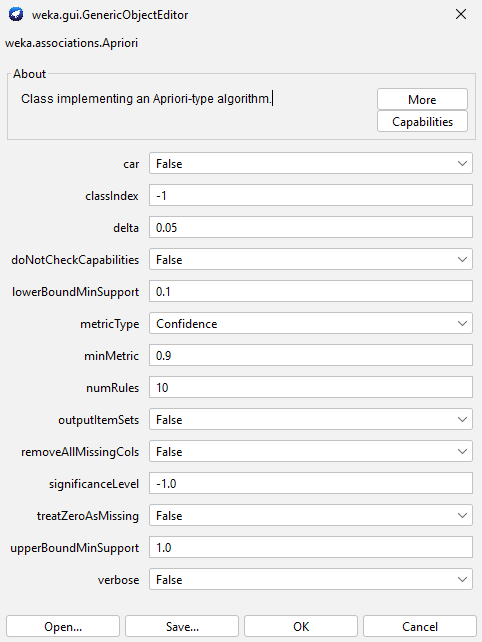

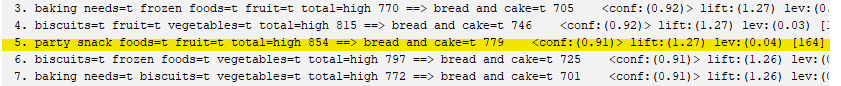

### *Análise da 2ª Regra:*

- A confiança (0.91) aponta que 91% das pessoas que compram os itens do Grupo A (salgadinhos para festas e frutas) tendem a comprar os produtos do Grupo B (pão e bolo).

- O Lift por ser (1.27), ou seja, maior que 1, aponta que o Grupo A e o Grupo B são positivamente associados (o antecedente impulsiona o consequente). Então, isso indica que comprar o Grupo A aumenta em 27% a probabilidade de comprar o Grupo B.

- O Leverage por ser (0.03) aponta que há uma diferença positiva entre a ocorrência real e a esperada da compra conjunta entre o Grupo A e o Grupo B. Ou seja, isso indica que a ocorrência conjunta é aproximadamente 3 pontos percentuais maior do que o esperado, reforçando que essa associação não ocorre ao acaso.

### *Cenário da 2ª Regra:*

Observa-se que consumidores que **compram itens do Grupo A (salgadinhos para festas e frutas) também possuem alta tendência de comprar itens do Grupo B (pão e bolo).** Esse comportamento pode estar relacionado a situações específicas como festas, **reuniões ou comemorações**, onde há a necessidade de maior variedade de alimentos.

### *Intervenção da 2ª Regra:*

Com base nessa regra, o supermercado pode adotar estratégias para aumentar as vendas, como posicionar os produtos do grupo B próximos aos itens do grupo A, criar combos promocionais voltados para festas e reuniões e oferecer descontos em compras conjuntas. Além disso, pode desenvolver o **“Kit Festa Prática”**, composto por salgadinhos para festa, frutas, pães e bolos, com o objetivo de atender consumidores que estão organizando pequenas comemorações. Esse kit proporciona mais praticidade ao reunir produtos frequentemente comprados em conjunto e pode ser oferecido com preço reduzido em relação à compra separada dos itens. Dessa forma, a estratégia contribui para o aumento do ticket médio e para a melhoria da experiência do cliente, tornando a compra mais rápida e eficiente.

--------------------------------------------------

## **3. Regra**

**Grupo A (baking needs=t fruit=t 1900)**

**Grupo B (vegetables=t) 1489**

Grupo A ==> Grupo B


*   Confiança: 0.78
*   Lift: 1.22
*   Leverage: 0.06

### Configurações do Apriori

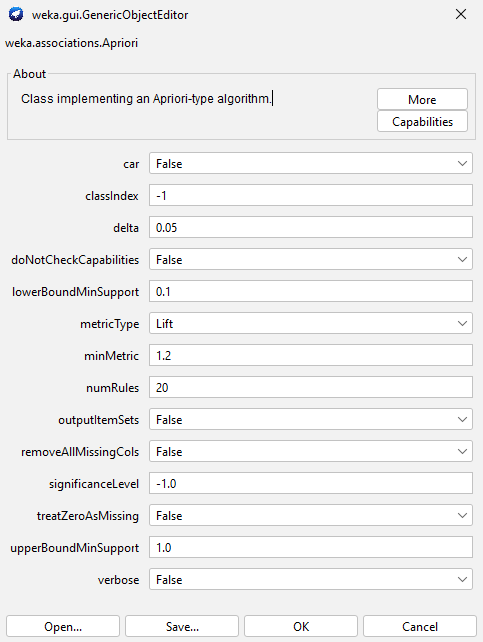

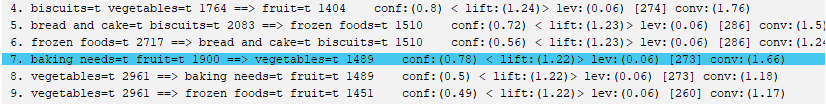

### *Análise da 3ª Regra:*

- A confiança (0.78) aponta que 78% das pessoas que compram os itens do Grupo A (produtos para preparo de alimentos e frutas), tendem a comprar os produtos do Grupo B (vegetais). Embora seja menor que as regras anteriores, ainda representa uma associação relevante.

- O Lift por ser (1.22), ou seja maior que 1, indica que o Grupo A e o Grupo B são positivamente associados. Isso significa que a compra do Grupo A aumenta em aproximadamente 22% a probabilidade de compra do Grupo B.

- O Leverage (0.06) aponta uma diferença positiva entre a ocorrência real e a esperada da compra conjunta, indicando que essa associação ocorre cerca de 6 pontos percentuais acima do esperado, sendo mais significativa que nas regras anteriores.

### *Cenário da 3ª Regra:*

Observa-se que **consumidores que compram itens do Grupo A (produtos para preparo de alimentos e frutas) também possuem tendência a comprar vegetais.** Esse comportamento pode estar relacionado a um perfil de consumo mais voltado ao **preparo de refeições completas e possivelmente mais saudáveis, indicando planejamento alimentar e compras mais estruturadas.**

### *Intervenção da 3ª Regra:*

Com base nessa regra, o supermercado pode adotar estratégias como posicionar ingredientes culinários próximos a hortifrútis, incentivar a compra conjunta por meio de promoções e criar kits voltados para preparo de refeições, como um **“Kit Refeição Saudável”**, contendo frutas, vegetais e itens básicos de preparo. **Essa estratégia pode aumentar o volume de vendas e incentivar hábitos de consumo mais completos.**

--------------------------------------------------